This notebook demonstrates a simple linear regression analysis using Python to model Salary based on Years of Experience.

Read the dataset

In [1]:
import pandas as pd
dataset = pd.read_csv("regression_data.csv")

Fit a linear model

In [2]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(dataset[["YearsExperience"]], dataset[["Salary"]])

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Evaluate the model by calculating R-squared

In [3]:
model.score(dataset[["YearsExperience"]], dataset[["Salary"]])  # R-squared

0.7851515863136573

This cell calculates the slope, intercept and the correlation coefficient. Slope indicates how much salary changes for each additional year of experience. Intercept is the predicted salary when experience is zero.Correlation coefficient (r) measures the strength of the relationship.

In [4]:
from scipy.stats import linregress
slope, intercept, r_value, p_value, std_err = linregress(dataset["YearsExperience"], dataset["Salary"])
print("Slope:", slope)
print("Intercept:", intercept)
print("Correlation coefficient (r):", r_value)

Slope: 8285.292099903525
Intercept: 29203.522671240222
Correlation coefficient (r): 0.8860877983098836


This cell calculates the Mean Squared Error (MSE). MSE measures prediction error.

In [5]:
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(dataset["Salary"], model.predict(dataset[["YearsExperience"]]))
print("Mean Squared Error:", mse)

Mean Squared Error: 17523844.08290278


Plotting the data and the model

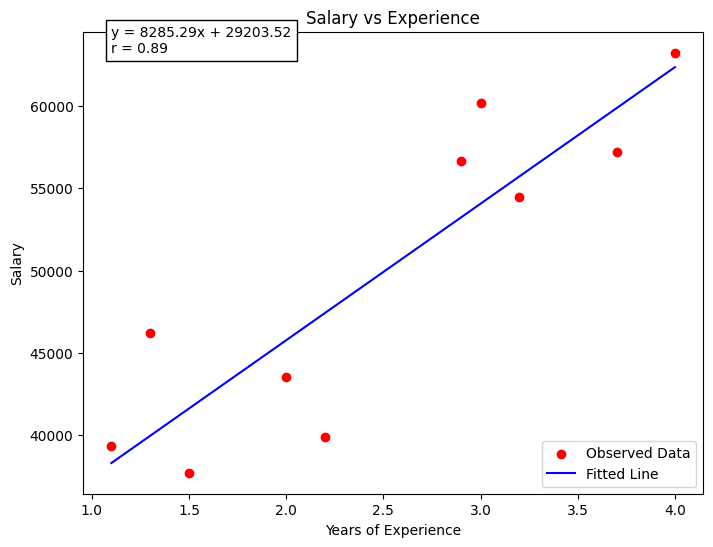

In [6]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
plt.scatter(dataset["YearsExperience"], dataset["Salary"], color="red", label="Observed Data")
plt.plot(dataset["YearsExperience"], model.predict(dataset[["YearsExperience"]]), color="blue", label="Fitted Line")
plt.text(min(dataset["YearsExperience"]),max(dataset["Salary"]),f"y = {slope:.2f}x + {intercept:.2f}\nr = {r_value:.2f}", bbox=dict(facecolor="white"))
plt.title("Salary vs Experience")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.legend()
plt.show()